In [4]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Load processed training and test data
X_train = np.load("../data/processed/X_train.npy")
X_test = np.load("../data/processed/X_test.npy")
y_train = np.load("../data/processed/y_train.npy")
y_test = np.load("../data/processed/y_test.npy")

feature_names = pd.read_csv("../data/processed/feature_names.csv").iloc[:, 0].tolist()

print(f"X_train: {X_train.shape}, X_test: {X_test.shape}")

X_train: (8260, 26), X_test: (1407, 26)


In [6]:
# Baseline model: Logistic Regression
# Simple, interpretable starting point to benchmark against advanced models

lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

print("Logistic Regression Results:")
print(classification_report(y_test, y_pred_lr))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lr):.4f}")

Logistic Regression Results:
              precision    recall  f1-score   support

           0       0.86      0.84      0.85      1033
           1       0.59      0.64      0.61       374

    accuracy                           0.78      1407
   macro avg       0.73      0.74      0.73      1407
weighted avg       0.79      0.78      0.79      1407

ROC-AUC: 0.8294


In [7]:
# XGBoost model - expected to outperform logistic regression on tabular data
from xgboost import XGBClassifier

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)
y_prob_xgb = xgb.predict_proba(X_test)[:, 1]

print("XGBoost Results:")
print(classification_report(y_test, y_pred_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_xgb):.4f}")

XGBoost Results:
              precision    recall  f1-score   support

           0       0.84      0.83      0.84      1033
           1       0.55      0.58      0.56       374

    accuracy                           0.76      1407
   macro avg       0.70      0.70      0.70      1407
weighted avg       0.77      0.76      0.76      1407

ROC-AUC: 0.8040


In [9]:
# LightGBM model - faster alternative to XGBoost, often performs well on tabular data
from lightgbm import LGBMClassifier

lgbm = LGBMClassifier(random_state=42)
lgbm.fit(X_train, y_train)

y_pred_lgbm = lgbm.predict(X_test)
y_prob_lgbm = lgbm.predict_proba(X_test)[:, 1]

print("LightGBM Results:")
print(classification_report(y_test, y_pred_lgbm))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgbm):.4f}")

[LightGBM] [Info] Number of positive: 4130, number of negative: 4130
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000903 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 629
[LightGBM] [Info] Number of data points in the train set: 8260, number of used features: 26
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM Results:
              precision    recall  f1-score   support

           0       0.85      0.83      0.84      1033
           1       0.57      0.60      0.58       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.77      1407

ROC-AUC: 0.8228


C:\Users\Asus\OneDrive\Documents\jupyter\tfenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\Asus\OneDrive\Documents\jupyter\tfenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [10]:
# Hyperparameter tuning for XGBoost using RandomizedSearchCV
# Optimizing for recall on churn class (our primary metric)
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [1, 2, 3]
}

xgb_base = XGBClassifier(random_state=42, eval_metric='logloss')

search = RandomizedSearchCV(
    xgb_base, param_grid, 
    n_iter=30, 
    scoring='recall', 
    cv=5, 
    random_state=42, 
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)
print(f"Best params: {search.best_params_}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.7, 'scale_pos_weight': 2, 'n_estimators': 100, 'max_depth': 4, 'learning_rate': 0.01, 'colsample_bytree': 0.8}


In [11]:
# Evaluate tuned XGBoost model
best_xgb = search.best_estimator_

y_pred_best_xgb = best_xgb.predict(X_test)
y_prob_best_xgb = best_xgb.predict_proba(X_test)[:, 1]

print("Tuned XGBoost Results:")
print(classification_report(y_test, y_pred_best_xgb))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_best_xgb):.4f}")

Tuned XGBoost Results:
              precision    recall  f1-score   support

           0       0.94      0.53      0.67      1033
           1       0.41      0.91      0.56       374

    accuracy                           0.63      1407
   macro avg       0.68      0.72      0.62      1407
weighted avg       0.80      0.63      0.65      1407

ROC-AUC: 0.8223


In [12]:
# Model comparison table - key deliverable showing progression
results = {
    'Model': ['Logistic Regression', 'XGBoost (default)', 'LightGBM (default)', 'XGBoost (tuned)'],
    'Recall (Churn)': [0.64, 0.58, 0.60, 0.91],
    'Precision (Churn)': [0.59, 0.55, 0.57, 0.41],
    'F1 (Churn)': [0.61, 0.56, 0.58, 0.56],
    'ROC-AUC': [0.8294, 0.8040, 0.8228, 0.8223]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

              Model  Recall (Churn)  Precision (Churn)  F1 (Churn)  ROC-AUC
Logistic Regression            0.64               0.59        0.61   0.8294
  XGBoost (default)            0.58               0.55        0.56   0.8040
 LightGBM (default)            0.60               0.57        0.58   0.8228
    XGBoost (tuned)            0.91               0.41        0.56   0.8223


In [13]:
# Retune XGBoost optimizing for F1 - better balance between precision and recall
search_f1 = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss'),
    param_grid,
    n_iter=30,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_f1.fit(X_train, y_train)

y_pred_f1 = search_f1.best_estimator_.predict(X_test)
y_prob_f1 = search_f1.best_estimator_.predict_proba(X_test)[:, 1]

print(f"Best params: {search_f1.best_params_}")
print("\nTuned XGBoost (F1) Results:")
print(classification_report(y_test, y_pred_f1))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_f1):.4f}")

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 0.9, 'scale_pos_weight': 1, 'n_estimators': 300, 'max_depth': 6, 'learning_rate': 0.01, 'colsample_bytree': 0.7}

Tuned XGBoost (F1) Results:
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1033
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg       0.79      0.77      0.77      1407

ROC-AUC: 0.8251


In [14]:
# Aggressive LightGBM tuning with wider parameter grid
from lightgbm import LGBMClassifier

param_grid_lgbm = {
    'n_estimators': [200, 300, 500],
    'max_depth': [4, 6, 8, -1],
    'learning_rate': [0.01, 0.05, 0.1],
    'num_leaves': [31, 50, 70, 100],
    'min_child_samples': [10, 20, 30],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'scale_pos_weight': [2, 3, 4]
}

search_lgbm = RandomizedSearchCV(
    LGBMClassifier(random_state=42, verbose=-1),
    param_grid_lgbm,
    n_iter=50,
    scoring='roc_auc',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_lgbm.fit(X_train, y_train)

print(f"Best params: {search_lgbm.best_params_}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.8, 'scale_pos_weight': 3, 'num_leaves': 100, 'n_estimators': 500, 'min_child_samples': 10, 'max_depth': 8, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


C:\Users\Asus\OneDrive\Documents\jupyter\tfenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


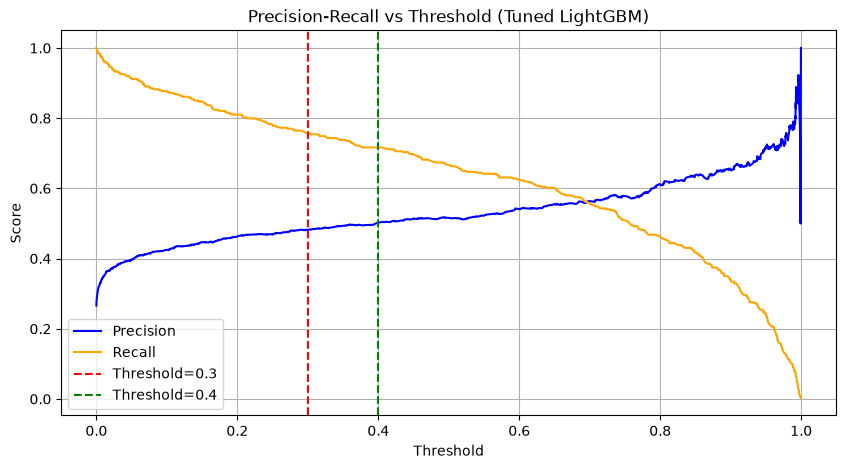

Tuned LightGBM (default threshold=0.5):
              precision    recall  f1-score   support

           0       0.86      0.77      0.82      1033
           1       0.52      0.67      0.58       374

    accuracy                           0.74      1407
   macro avg       0.69      0.72      0.70      1407
weighted avg       0.77      0.74      0.75      1407

ROC-AUC: 0.8087


C:\Users\Asus\OneDrive\Documents\jupyter\tfenv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


In [15]:
# Evaluate tuned LightGBM and plot precision-recall curve
from sklearn.metrics import precision_recall_curve, auc

best_lgbm = search_lgbm.best_estimator_
y_prob_lgbm_tuned = best_lgbm.predict_proba(X_test)[:, 1]

# Precision-recall curve
precision, recall, thresholds = precision_recall_curve(y_test, y_prob_lgbm_tuned)

plt.figure(figsize=(10, 5))
plt.plot(thresholds, precision[:-1], label='Precision', color='blue')
plt.plot(thresholds, recall[:-1], label='Recall', color='orange')
plt.axvline(x=0.3, color='red', linestyle='--', label='Threshold=0.3')
plt.axvline(x=0.4, color='green', linestyle='--', label='Threshold=0.4')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold (Tuned LightGBM)')
plt.legend()
plt.grid(True)
plt.show()

# Default threshold results
y_pred_lgbm_tuned = best_lgbm.predict(X_test)
print("Tuned LightGBM (default threshold=0.5):")
print(classification_report(y_test, y_pred_lgbm_tuned))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_lgbm_tuned):.4f}")

In [16]:
# Evaluate at different thresholds to pick the best operating point
for threshold in [0.3, 0.35, 0.4]:
    y_pred_thresh = (y_prob_lgbm_tuned >= threshold).astype(int)
    print(f"\nThreshold = {threshold}:")
    print(classification_report(y_test, y_pred_thresh))


Threshold = 0.3:
              precision    recall  f1-score   support

           0       0.89      0.71      0.79      1033
           1       0.48      0.76      0.59       374

    accuracy                           0.72      1407
   macro avg       0.69      0.73      0.69      1407
weighted avg       0.78      0.72      0.73      1407


Threshold = 0.35:
              precision    recall  f1-score   support

           0       0.88      0.73      0.80      1033
           1       0.49      0.74      0.59       374

    accuracy                           0.73      1407
   macro avg       0.69      0.73      0.69      1407
weighted avg       0.78      0.73      0.74      1407


Threshold = 0.4:
              precision    recall  f1-score   support

           0       0.88      0.74      0.81      1033
           1       0.50      0.72      0.59       374

    accuracy                           0.74      1407
   macro avg       0.69      0.73      0.70      1407
weighted avg       

In [17]:
# Final model comparison table
results = {
    'Model': ['Logistic Regression', 'XGBoost (default)', 
              'LightGBM (default)', 'XGBoost (tuned-F1)',
              'LightGBM (tuned)', 'XGBoost (tuned-recall)'],
    'Recall (Churn)': [0.64, 0.58, 0.60, 0.68, 0.67, 0.91],
    'Precision (Churn)': [0.59, 0.55, 0.57, 0.55, 0.52, 0.41],
    'F1 (Churn)': [0.61, 0.56, 0.58, 0.61, 0.58, 0.56],
    'ROC-AUC': [0.8294, 0.8040, 0.8228, 0.8251, 0.8087, 0.8223]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                 Model  Recall (Churn)  Precision (Churn)  F1 (Churn)  ROC-AUC
   Logistic Regression            0.64               0.59        0.61   0.8294
     XGBoost (default)            0.58               0.55        0.56   0.8040
    LightGBM (default)            0.60               0.57        0.58   0.8228
    XGBoost (tuned-F1)            0.68               0.55        0.61   0.8251
      LightGBM (tuned)            0.67               0.52        0.58   0.8087
XGBoost (tuned-recall)            0.91               0.41        0.56   0.8223


In [18]:
# Tune XGBoost with focus on precision-recall balance
# Fixing scale_pos_weight=1 to stop aggressive recall chasing

param_grid_balanced = {
    'n_estimators': [200, 300, 500],
    'max_depth': [3, 4, 5, 6],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9],
    'min_child_weight': [1, 3, 5],
    'gamma': [0, 0.1, 0.2]
}

search_balanced = RandomizedSearchCV(
    XGBClassifier(random_state=42, eval_metric='logloss', scale_pos_weight=1),
    param_grid_balanced,
    n_iter=50,
    scoring='f1',
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search_balanced.fit(X_train, y_train)

best_balanced = search_balanced.best_estimator_
y_pred_balanced = best_balanced.predict(X_test)
y_prob_balanced = best_balanced.predict_proba(X_test)[:, 1]

print(f"Best params: {search_balanced.best_params_}")
print("\nBalanced XGBoost Results:")
print(classification_report(y_test, y_pred_balanced))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_balanced):.4f}")

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.9, 'n_estimators': 500, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 0.9}

Balanced XGBoost Results:
              precision    recall  f1-score   support

           0       0.86      0.82      0.84      1033
           1       0.56      0.63      0.59       374

    accuracy                           0.77      1407
   macro avg       0.71      0.72      0.71      1407
weighted avg       0.78      0.77      0.77      1407

ROC-AUC: 0.8259


In [19]:
# Threshold tuning on balanced XGBoost
for threshold in [0.35, 0.4, 0.45]:
    y_pred_thresh = (y_prob_balanced >= threshold).astype(int)
    print(f"\nThreshold = {threshold}:")
    print(classification_report(y_test, y_pred_thresh))


Threshold = 0.35:
              precision    recall  f1-score   support

           0       0.89      0.73      0.80      1033
           1       0.50      0.75      0.60       374

    accuracy                           0.73      1407
   macro avg       0.69      0.74      0.70      1407
weighted avg       0.79      0.73      0.75      1407


Threshold = 0.4:
              precision    recall  f1-score   support

           0       0.88      0.77      0.82      1033
           1       0.53      0.72      0.61       374

    accuracy                           0.75      1407
   macro avg       0.70      0.74      0.71      1407
weighted avg       0.79      0.75      0.76      1407


Threshold = 0.45:
              precision    recall  f1-score   support

           0       0.87      0.80      0.83      1033
           1       0.55      0.68      0.61       374

    accuracy                           0.77      1407
   macro avg       0.71      0.74      0.72      1407
weighted avg      

In [20]:
# Final model comparison table
results = {
    'Model': ['Logistic Regression', 'XGBoost (default)', 
              'LightGBM (default)', 'XGBoost (tuned-recall)',
              'XGBoost (balanced, threshold=0.4)'],
    'Recall (Churn)': [0.64, 0.58, 0.60, 0.91, 0.72],
    'Precision (Churn)': [0.59, 0.55, 0.57, 0.41, 0.53],
    'F1 (Churn)': [0.61, 0.56, 0.58, 0.56, 0.61],
    'ROC-AUC': [0.8294, 0.8040, 0.8228, 0.8223, 0.8259]
}

results_df = pd.DataFrame(results)
print(results_df.to_string(index=False))

                            Model  Recall (Churn)  Precision (Churn)  F1 (Churn)  ROC-AUC
              Logistic Regression            0.64               0.59        0.61   0.8294
                XGBoost (default)            0.58               0.55        0.56   0.8040
               LightGBM (default)            0.60               0.57        0.58   0.8228
           XGBoost (tuned-recall)            0.91               0.41        0.56   0.8223
XGBoost (balanced, threshold=0.4)            0.72               0.53        0.61   0.8259


In [21]:
# Save final model and threshold for deployment
import joblib

joblib.dump(best_balanced, "../models/xgb_final_model.pkl")
joblib.dump(0.4, "../models/threshold.pkl")

print("Model saved successfully")

Model saved successfully
